# Recreate Rubiks Cube env

Create a custom gymnasuim environment representing a rubiks cube. 


Afterwards, create a model to solve it

## Env

In [1]:

from __future__ import annotations

from typing import Any, Optional

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import random

from pathlib import Path
import torch

In [2]:
class RubiksCube(gym.Env):
    metadata = {
        "render_modes": ["human", "rgb_array", "ansi"],#unused
        "render_fps": 30,#unused
    }

    def __init__(
        self,
        render_mode: Optional[str] = None,
        max_steps: int = 50,
    ):
        super().__init__()

        self.render_mode = render_mode
        self.max_steps = max_steps

        # Example: 4 discrete actions
        self.action_space = spaces.Discrete(12)

        # Example: 1D continuous observation vector of length 5
        self.observation_space = spaces.Box(
            low=0,
            high=5,
            shape=(54*6,),#6 3x3 faces in a 1d array. each of which is one of 6 colors represented as an int 0 to 5
            dtype=np.int8, #color
        )

        self.state = []
        self.step_count = 0

        # Optional render state
        self.window = None
        self.clock = None

    def _get_obs(self) -> np.ndarray:
        colors = np.array([int(p[3]) for p in self.state])
        return np.eye(int(colors.max())+1,dtype=np.float64)[colors].flatten()

    def _get_info(self) -> dict[str, Any]:
        return {
            "step_count": self.step_count,
            #num correct squares
            #num correct faces
        }

    def reset(
            self,
            *,
            seed: Optional[int] = None,
            options: Optional[dict[str, Any]] = None,
            n_scramble = 26
            ) -> tuple[np.ndarray, dict[str, Any]]:
        super().reset(seed=seed)

        self.step_count = 0

        # solved initial state
        self.state = self.place_points_on_cube_faces()

        # make random moves n times
        for _ in range(n_scramble):
            self.move(random.randint(0,11))
        
        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, info

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        assert self.action_space.contains(action), f"Invalid action: {action}"

        self.step_count += 1
        #take action
        self.move(action)
        
        
        reward = self._get_reward()

        # ---- Termination logic (task-defined) ----
        terminated = self._check_cube_completion()
        # ------------------------------------------

        # ---- Truncation logic (outside MDP, e.g. time limit) ----
        truncated = self.step_count >= self.max_steps
        # ---------------------------------------------------------

        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, reward, terminated, truncated, info
        
    def _check_cube_completion(self):
        faces = ['front','back','left','right','top','bottom']
        is_completed = True
        for face in faces:
            face_pts,_ = self.get_face(self.state,face,exclude_sides=True)
            face_colors = [p[3] for p in face_pts]
            if len(set(face_colors))> 1:
                is_completed = False
                break
        if is_completed:
            print('COMPLETE///////////////////////////////////////////////')
        return is_completed
        
    def _get_reward(self,reward_type='absolute'):
        is_completed = self._check_cube_completion()
        if reward_type == 'absolute':
            #only reward for completing cube
            return is_completed * 10
        elif reward_type == 'absolute_drain': 
            #large reward for completing cube, but small negative reward each step
            return (var * 1000) + (var==False) * -1
        # elif too many steps, large negative
    
            
    def render(self,radius=1.0, sphere_alpha=0.2, point_color='red', point_size=50):
        # def plot_points_on_sphere(points, radius=1.0, sphere_alpha=0.2, point_color='red', point_size=50):
        """
        Plot a list of 3D Cartesian coordinates on a sphere.
    
        Parameters
        ----------
        points : list of tuple[float, float, float]
            List of (x, y, z) coordinates.
        radius : float
            Radius of the sphere.
        sphere_alpha : float
            Transparency of the sphere surface.
        point_color : str
            Color of plotted points.
        point_size : int
            Size of plotted points.
        """
        points = self.state
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
    
        # Create sphere surface
        u = np.linspace(0, 2 * np.pi, 100)
        v = np.linspace(0, np.pi, 100)
        x = radius * np.outer(np.cos(u), np.sin(v))
        y = radius * np.outer(np.sin(u), np.sin(v))
        z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    
        ax.plot_surface(x, y, z, color='lightblue', alpha=sphere_alpha, edgecolor='none')
    
        # Plot input points
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   # color=points[:,3],
                   c=points[:,3],
                   cmap='viridis',
                   s=point_size)
    
        # Keep aspect ratio equal
        ax.set_box_aspect([1, 1, 1])
    
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title("Points on a Sphere")
    
        plt.show()

    def close(self):
        #undo anything opened from self.render
        plt.close()

    def rotate_point_on_sphere(self,point, axis, direction=1):
        """
        Rotate a 3D point on a sphere by +/- 90 degrees around a given axis.
    
        Parameters
        ----------
        point : tuple or array-like
            The (x, y, z) point to rotate.
        axis : tuple or array-like
            The axis of rotation as a 3D vector.
        direction : int
            +1 for +90 degrees, -1 for -90 degrees.
    
        Returns
        -------
        np.ndarray
            Rotated point as a length-3 array.
        """
        color = point[3]
        point = point[:3]
        p = np.asarray(point, dtype=float)
        k = np.asarray(axis, dtype=float)
    
        if np.linalg.norm(k) == 0:
            raise ValueError("axis must be non-zero")
        if direction not in (+1, -1):
            raise ValueError("direction must be +1 or -1")
    
        k = k / np.linalg.norm(k)
        theta = direction * np.pi / 2  # 90 degrees
    
        # Rodrigues' rotation formula
        p_rot = (
            p * np.cos(theta)
            + np.cross(k, p) * np.sin(theta)
            + k * np.dot(k, p) * (1 - np.cos(theta))
        )
    
        return [p_rot[0],p_rot[1],p_rot[2],color]

    def rotate_points_on_sphere(self,points, axis, direction=1):
        return np.array([self.rotate_point_on_sphere(point=p,axis=axis,direction=direction) for p in points])

    def get_face(self,points,face,exclude_sides=False): 
        face = face.lower()
        cut = 0.25
        if exclude_sides:
            cut+=0.25
        if face == 'top':
            face_points = [p for p in points if p[2]>cut]
            remainder = [p for p in points if not p[2]>cut]
        elif face == 'bottom':
            face_points = [p for p in points if p[2]<-cut]
            remainder = [p for p in points if not p[2]<-cut]
        elif face == 'left':
            face_points = [p for p in points if p[0]<-cut]
            remainder = [p for p in points if not p[0]<-cut]
        elif face == 'right':
            face_points = [p for p in points if p[0]>cut]
            remainder = [p for p in points if not p[0]>cut]
        elif face == 'front':
            face_points = [p for p in points if p[1]<-cut]
            remainder = [p for p in points if not p[1]<-cut]
        elif face == 'back':
            face_points = [p for p in points if p[1]>cut]
            remainder = [p for p in points if not p[1]>cut]
        return np.array(face_points),np.array(remainder)
        
    def move_face(self,points,face,direction):
        '''
        face: one of the following: top, bottom, left, right, front, back
        direction: -1 or 1
        '''
        face = face.lower()
        if face in ['top','bottom']:
            axis = (0,0,1)
        elif face in ['left','right']:
            axis = (1,0,0)
        elif face in ['front','back']:
            axis = (0,1,0)
        points_sub, remainder = self.get_face(points,face)
        points_sub = self.rotate_points_on_sphere(points_sub,axis=axis,direction=direction)
        return np.concat((points_sub,remainder))

    def move(self,action):
        action_map = {
            0:['top',1],
            1:['top',-1],
            2:['bottom',1],
            3:['bottom',-1],
            4:['left',1],
            5:['left',-1],
            6:['right',1],
            7:['right',-1],
            8:['front',1],
            9:['front',-1],
            10:['back',1],
            11:['back',-1],
        }
        points=self.state
        
        choice = action_map[action]

        def sort_by_first_three(arr):
            arr = np.asarray(arr)
            
            if arr.ndim != 2 or arr.shape[1] != 4:
                raise ValueError("arr must have shape (n, 4)")
            
            idx = np.lexsort((arr[:, 2], arr[:, 1], arr[:, 0]))
            return arr[idx]
        self.state = sort_by_first_three(self.move_face(points=points,face=choice[0],direction=choice[1]))
        
    def place_points_on_cube_faces(self,grid_range=0.5):
        """Place 9 points on each of the 6 cube-like faces of the sphere.
           Use `grid_range` to control how tightly the points are clustered (0.1 to 1.0)."""
    
        points = []
        radius = 1.0
        center = (0,0,0)
        # Grid from -grid_range to grid_range in 3 steps (local coordinates)
        steps = np.linspace(-grid_range, grid_range, 3)
        
        # For each face (x+, x-, y+, y-, z+, z-)
        for face in ['x+', 'x-', 'y+', 'y-', 'z+', 'z-']:
            for a in steps:
                for b in steps:
                    # Get local coordinates on the cube face
                    if face == 'x+':
                        color = 0
                        x, y, z = 1, a, b
                    elif face == 'x-':
                        # color = 7 #i want to do 7 so colors are different enough, but for now i am lazily using these values for onehot as well
                        color = 1
                        x, y, z = -1, a, b
                    elif face == 'y+':
                        color = 2
                        x, y, z = a, 1, b
                    elif face == 'y-':
                        color = 3
                        x, y, z = a, -1, b
                    elif face == 'z+':
                        color = 4
                        x, y, z = a, b, 1
                    elif face == 'z-':
                        color = 5
                        x, y, z = a, b, -1
                    
                    # Normalize to project onto the sphere
                    norm = np.linalg.norm([x, y, z])
                    x_norm = x / norm
                    y_norm = y / norm
                    z_norm = z / norm
                    
                    # Scale by radius and shift to center
                    x_global = radius * x_norm + center[0]
                    y_global = radius * y_norm + center[1]
                    z_global = radius * z_norm + center[2]
                    
                    points.append((x_global, y_global, z_global,color))
        return points        

### Test reward

In [3]:
env = RubiksCube()
env.reset()
print('reward: ',env._get_reward())
env.get_face(env.state,'right',exclude_sides=True)[0]
# env.get_face(env.state,'bottom')[0]


reward:  0


array([[ 8.16496581e-01, -4.08248290e-01, -4.08248290e-01,
         2.00000000e+00],
       [ 8.16496581e-01,  4.08248290e-01, -4.08248290e-01,
         2.00000000e+00],
       [ 8.16496581e-01,  4.08248290e-01,  4.08248290e-01,
         1.00000000e+00],
       [ 8.16496581e-01, -4.08248290e-01,  4.08248290e-01,
         5.00000000e+00],
       [ 8.94427191e-01,  2.73839349e-16, -4.47213595e-01,
         0.00000000e+00],
       [ 8.94427191e-01, -4.47213595e-01,  1.36919675e-16,
         3.00000000e+00],
       [ 8.94427191e-01,  4.47213595e-01, -2.73839349e-17,
         2.00000000e+00],
       [ 8.94427191e-01, -3.69778549e-32,  4.47213595e-01,
         2.00000000e+00],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

### Test movement

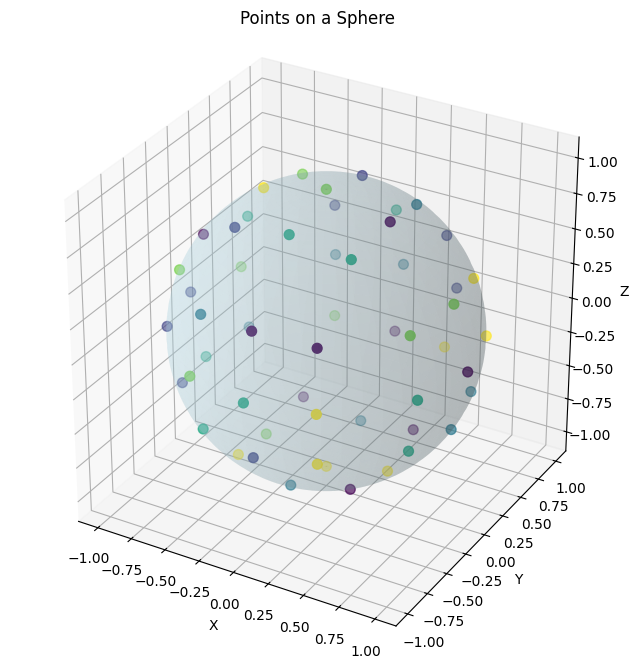

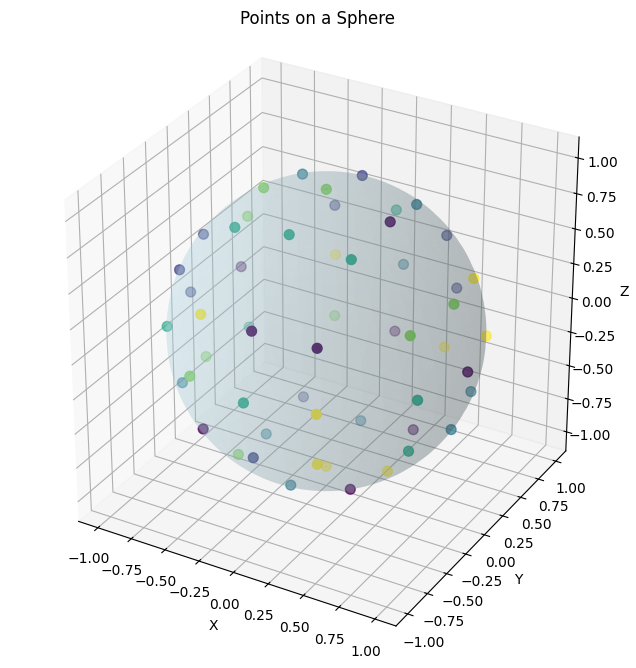

In [4]:
env = RubiksCube()
env.reset()
env.render()
env.move(5)
env.render()


### Test reward

## Model

### Define Model

In [5]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# GAMMA = 0.99
GAMMA = 1.0
LR = 1e-4
HIDDEN_SIZE = 128*(2**5)
NUM_EPISODES = 500
# NUM_EPISODES = 20

class RNNPolicy(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()
        self.input_proj = nn.Linear(obs_size, hidden_size,dtype=torch.float32)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.policy_head = nn.Linear(hidden_size, n_actions)
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        inpt = self.input_proj(x)
        x = torch.tanh(inpt)
        x = x.unsqueeze(1)              # [batch, 1, hidden]
        out, h = self.gru(x, h)         # out: [batch, 1, hidden]
        out = out.squeeze(1)            # [batch, hidden]
        logits = self.policy_head(out)
        value = self.value_head(out).squeeze(-1)
        return logits, value, h

    def init_hidden(self, batch_size=1):
        return torch.zeros(1, batch_size, HIDDEN_SIZE, device=DEVICE)

In [6]:
env = RubiksCube()
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

model = RNNPolicy(obs_size, HIDDEN_SIZE, n_actions).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

### Train Model

In [7]:
def run_episode(env, model, episode_number,action_hist):
    obs, info = env.reset(n_scramble = episode_number//100 if episode_number < 250 else 25)
    # obs, info = env.reset(n_scramble = 1)
    
    h = model.init_hidden(batch_size=1) #init hidden state

    log_probs = []
    values = []
    rewards = []

    done = False
    total_reward = 0.0
    alpha=2**4
    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)  #convert obs to tensor
        logits, value, h = model(obs_t, h) # get model prediciton
        pre_mod_argmax = logits.argmax()
        #modify logits by reducing the likelyhood of choosing popular actions
        # action_hist_norm = np.array(action_hist)/(action_hist.max()+1e-8)
        # action_hist_norm = torch.from_numpy(action_hist_norm).to(logits.device).type_as(logits)
        # logits = logits/(action_hist_norm*alpha)
        penalty = alpha * (action_hist / (action_hist.max() + 1e-8))  # in [0, alpha]
        penalty = torch.from_numpy(penalty).to(logits.device).type_as(logits)
        logits = logits - penalty

        #print if modification was useless
        # if logits.argmax() == pre_mod_argmax:
            # print('logits argmax unchanged')
            # print('penalty',penalty)
            # print('logits',logits)
            # print('action_hist',action_hist)
        
        
        #Get action by sampling probabilities
        probs = torch.softmax(logits, dim=-1) #convert model output to probabilities
        dist = Categorical(probs)
        action = dist.sample()
        action_hist[action]+=1

        #advance state
        next_obs, reward, terminated, truncated, info = env.step(action.item()) #get observations and  from env
        done = terminated or truncated

        #record info
        log_probs.append(dist.log_prob(action))
        values.append(value)
        rewards.append(reward)

        obs = next_obs
        total_reward += reward 
    return log_probs, values, rewards, total_reward,action_hist

def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma * R # add discounted future rewards to current reward step
        returns.append(R) # log reward
    returns.reverse()
    returns = torch.tensor(returns, dtype=torch.float32, device=DEVICE) #convert to tensor
    # returns = (returns - returns.mean()) / (returns.std() + 1e-8) # normalize 
    returns = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8) # normalize 
    return returns
    
def load_or_create_model(model_class, some_path, device="cuda", *model_args, **model_kwargs):
    model = model_class(*model_args, **model_kwargs)
    path = Path(some_path)

    if path.exists():
        state_dict = torch.load(path, map_location=device)
        model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    return model


In [ ]:
save_path = 'models/rubiks_solver_4096_hidden515.pth'
model = load_or_create_model(RNNPolicy,save_path,obs_size=obs_size, hidden_size=HIDDEN_SIZE, n_actions=n_actions)
optimizer = optim.Adam(model.parameters(), lr=LR)

env = RubiksCube()
env.reset(n_scramble=0)

reward_history = []
action_history = []
loss_history = []
episode_action_hist = np.array([1e-8] * 12)

for episode in range(1, NUM_EPISODES + 1):
    model.train()
    before = []
    for p in model.parameters():
        before.append(p.detach().clone())
    log_probs, values, rewards, total_reward,episode_action_hist = run_episode(env, model,episode_number=episode,action_hist=episode_action_hist)
    action_history.append(episode_action_hist)
    returns = compute_returns(rewards, GAMMA)

    log_probs = torch.cat(log_probs)
    values = torch.cat(values)

    advantages = returns - values.detach()
    policy_loss = -(log_probs * advantages).sum()
    value_loss = nn.functional.mse_loss(values, returns)
    loss = policy_loss + 0.5 * value_loss
    loss_history.append(loss)
    
    optimizer.zero_grad()
    loss.backward()
    # nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    for name, p in model.named_parameters():
        if p.requires_grad and not torch.isfinite(p).all():
            print("Non-finite param after step:", name)
            print("param min/max:", p.min().item(), p.max().item())
            break
    reward_history.append(total_reward)

    if episode % 10 == 0:
        avg_reward = np.mean(reward_history[-10:])
        print(f"Episode {episode:4d} | avg reward {avg_reward:7.2f}")

    if episode % 1000 == 0:
        plt.subplot(1,2,1)
        plt.title('Loss per Episode')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.plot([hist.cpu().detach().numpy() for hist in loss_history])
        
        plt.subplot(1,2,2)
        plt.title('Action Frequency')
        plt.ylabel('count')
        plt.xlabel('action')
        # onehot_actions = [np.array(action_record).flatten() for action_record in action_history]#this isnt plotting correctly, action history isnt onehot
        plt.bar(np.arange(len(action_history[0])),sum(np.array(action_history)))
        
        
        plt.show()
    
    after = []
    for p in model.parameters():
        after.append(p.detach().clone())
    
    # check if anything changed
    none_changed = not(any((b != a).any().item() for b, a in zip(before, after)))
    if none_changed:
        print("Weights identical after training :(")
torch.save(model.state_dict(), save_path)

env.close()


### Plot Session Info

In [ ]:
plt.subplot(1,2,1)
plt.title('Loss per Episode')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.plot([hist.cpu().detach().numpy() for hist in loss_history])

plt.subplot(1,2,2)
plt.title('Action Frequency')
plt.ylabel('count')
plt.xlabel('action')
# onehot_actions = [np.array(action_record).flatten() for action_record in action_history]#this isnt plotting correctly, action history isnt onehot
plt.bar(np.arange(len(action_history[0])),sum(np.array(action_history)))


plt.show()

In [ ]:
#wilo: it looks like a high alpha is best for exploration (2**6)

In [ ]:
np.argmax(arr[0]),arr[0]

In [ ]:
print(sum(np.array(action_history)))

## Reward Test Gut-check

### Test Scramble

In [ ]:
env = RubiksCube()
env.reset(n_scramble=1)
print(env._get_reward())
env.render()
env.move(2)
env.render()
#passed

In [ ]:

# for _ in range(100)
env.reset(n_scramble=1)
env.render()
for act in range(0,11,2):
    env.move(act)
    print(env._get_reward())
    env.move(act+1)
for act in range(1,12,2):
    env.move(act)
    print(env._get_reward())
    if env._get_reward() == 1.0:
        env.render()
    env.move(act-1)
# env.render()
#passed

In [ ]:
env._get_reward()

### Test Inverse Move and Reward

In [ ]:
        # action_map = {
        #     0:['top',1],
        #     1:['top',-1],
        #     2:['bottom',1],
        #     3:['bottom',-1],
        #     4:['left',1],
        #     5:['left',-1],
        #     6:['right',1],
        #     7:['right',-1],
        #     8:['front',1],
        #     9:['front',-1],
        #     10:['back',1],
        #     11:['back',-1],
        # }